In [79]:
# Aumento de datos
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# crea el data set
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.15,
    zoom_range=[0.5, 1.5],
    validation_split=0.2
)

# generar set para entrenamiento y pruebas
data_gen_entrenamiento = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                                     batch_size=32,subset='training', shuffle=True,class_mode='categorical')
data_gen_pruebas = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                               batch_size=32, subset='validation', shuffle=True,class_mode='categorical')

Found 320 images belonging to 4 classes.
Found 80 images belonging to 4 classes.


In [80]:
import tensorflow as tf
base_model = tf.keras.applications.MobileNetV2(input_shape=(160,160,3), include_top=False, weights='imagenet')
base_model.trainable = False
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [81]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['acc'])
model_fit = model.fit(data_gen_entrenamiento,
                      steps_per_epoch=2,
                      epochs=120,
                      validation_data = data_gen_pruebas
)

/home/rodrigo/Documentos/Prog/Python/entV/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 3s/step - acc: 0.2083 - loss: 2.4248 - val_acc: 0.3500 - val_loss: 2.3982
Epoch 2/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.3750 - loss: 1.8111 - val_acc: 0.2625 - val_loss: 1.6381
Epoch 3/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.3958 - loss: 1.3803 - val_acc: 0.4875 - val_loss: 1.1200
Epoch 4/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.4688 - loss: 1.1280 - val_acc: 0.5750 - val_loss: 1.1496
Epoch 5/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - acc: 0.5000 - loss: 1.1390 - val_acc: 0.5875 - val_loss: 0.9757
Epoch 6/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - acc: 0.5625 - loss: 1.1589 - val_acc: 0.5375 - val_loss: 1.2152
Epoch 7/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.3958 - loss: 1.3924 - val_acc: 0.5000 - val_loss: 1.0592
Epoch 8/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.5625 - loss: 0.9769 - val_acc: 0.5625 - val_loss: 0.9456
Epoch 9/120
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.5521 - loss: 1.0219 - val_acc:

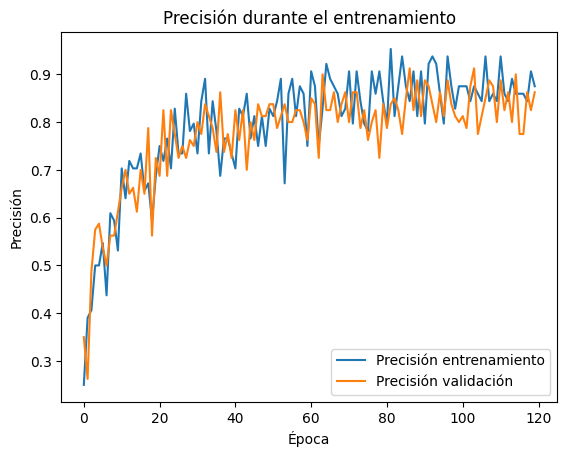

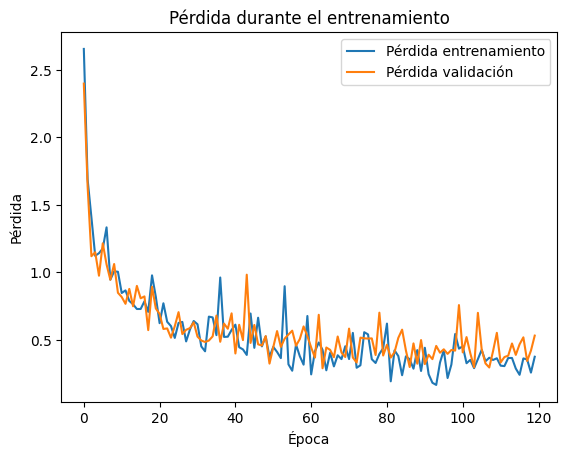

In [82]:
import matplotlib.pyplot as plt

# Graficar precisión
plt.plot(model_fit.history['acc'], label='Precisión entrenamiento')
plt.plot(model_fit.history['val_acc'], label='Precisión validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento')
plt.show()

# Graficar pérdida
plt.plot(model_fit.history['loss'], label='Pérdida entrenamiento')
plt.plot(model_fit.history['val_loss'], label='Pérdida validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()

In [83]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Ruta de la imagen a probar
#img_path = 'dataset/isis/rostro_3.jpg'  # Cambia por tu imagen
img_path = 'dataset/rodrigo/rostro_10.jpg'  # Cambia por tu imagen
#img_path = 'dataset/ignacio/rostro_30.jpg'  # Cambia por tu imagen

# Cargar y preprocesar la imagen
img = image.load_img(img_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normaliza igual que en el entrenamiento
img_array = np.expand_dims(img_array, axis=0)  # Añade dimensión batch
pred = model.predict(img_array)
print(f"Predicción bruta: {pred[0][0]}")

# Umbral para decidir si es "yo" o "no yo"
pred = model.predict(img_array)
clase = np.argmax(pred[0])
print(f"Clase predicha: {clase}, probabilidades: {pred[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicción bruta: 0.000395684881368652
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Clase predicha: 2, probabilidades: [3.9568488e-04 3.2839522e-02 8.1405860e-01 1.5270616e-01]


In [84]:
#guarda modelo
model.export('modelo_exportado')

INFO:tensorflow:Assets written to: modelo_exportado/assets


INFO:tensorflow:Assets written to: modelo_exportado/assets


Saved artifact at 'modelo_exportado'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_1594')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132401047439504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704917648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704912848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704918416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704916688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704919376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704918608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704917456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704917840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704920144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132401704

In [85]:
# Convierte directamente desde la carpeta SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model('modelo_exportado')
tflite_model = converter.convert()

# Guarda el modelo TFLite
with open('modelo_exportado/modelo.tflite', 'wb') as f:
    f.write(tflite_model)

W0000 00:00:1758324849.117152   11319 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1758324849.117176   11319 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-09-19 17:34:09.117451: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: modelo_exportado
2025-09-19 17:34:09.130251: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-09-19 17:34:09.130284: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: modelo_exportado
2025-09-19 17:34:09.276146: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-09-19 17:34:10.130084: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: modelo_exportado
2025-09-19 17:34:10.358144: I tensorflow/cc/saved_model/loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1240706 microseconds.


In [86]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,954 (9.87 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 164,486 (642.53 KB)

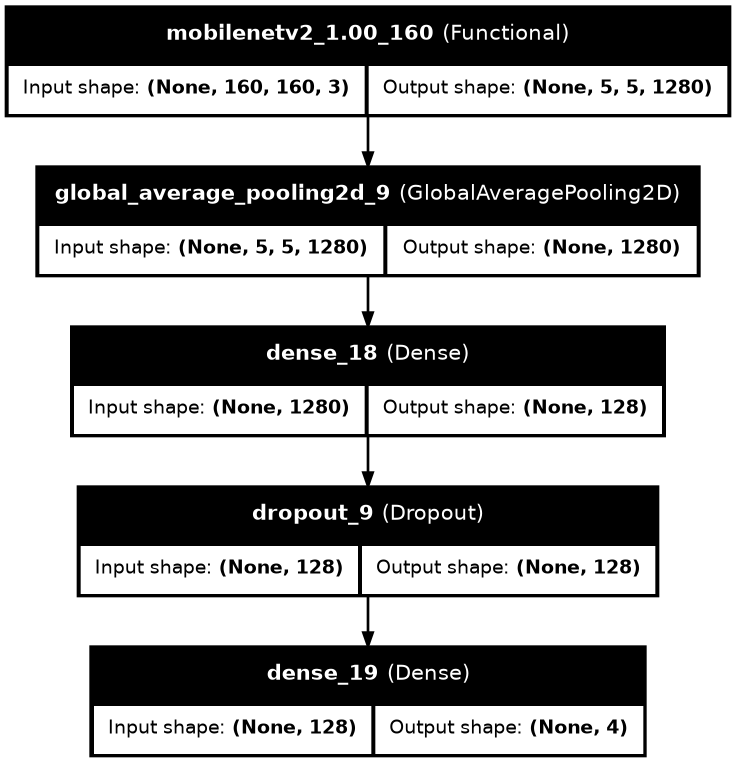

In [87]:
from tensorflow.keras.utils import plot_model
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',  # 'TB' para vertical, 'LR' para horizontal
    dpi=96,
    layer_range=None,  # Opcional: filtrar capas (ej. ['input_1', 'conv2d_1'])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step


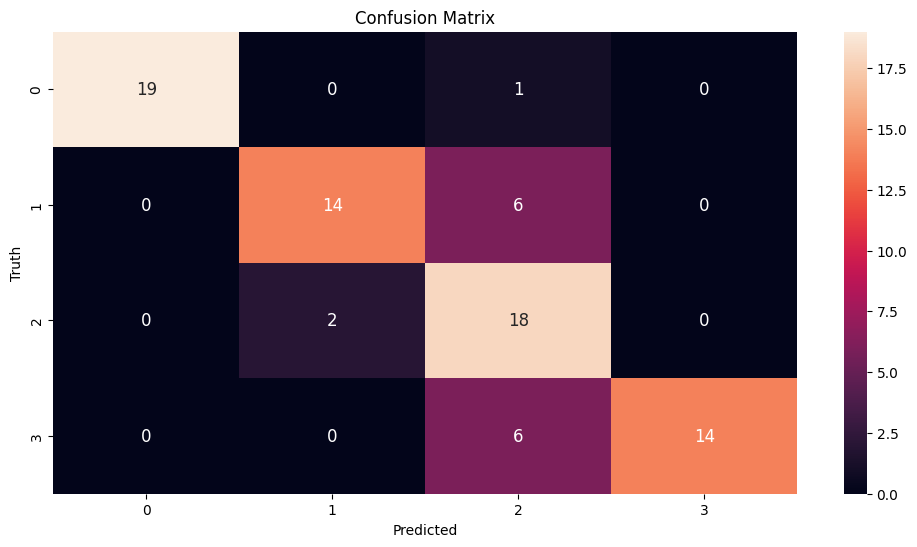

In [88]:
import numpy as np

# Obtener etiquetas verdaderas y predichas
y_true = []
y_pred = []

for i in range(len(data_gen_pruebas)):
    x_batch, y_batch = data_gen_pruebas[i]
    preds = model.predict(x_batch)
    y_true.extend(np.argmax(y_batch, axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

    # Opcional: detener si ya recorriste todo el set de validación
    if (i+1)*data_gen_pruebas.batch_size >= data_gen_pruebas.samples:
        break

import matplotlib.pyplot as plt
cm = tf.math.confusion_matrix(labels=y_true, predictions=y_pred)
# Plot the confusion matrix as a heatmap.
plt.figure(figsize=[12, 6])
import seaborn as sn

sn.heatmap(cm, annot=True, fmt="d", annot_kws={"size": 12})
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Truth")
plt.show()